# Data Science Intern Assignment
## Trader Performance vs Market Sentiment (Fear/Greed Index)

**Data:** Bitcoin Fear/Greed Index | Hyperliquid Historical Trades  


In [ ]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Image
sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

CHARTS = "../output/charts"
TABLES = "../output/tables"


## Part A : Data Preparation

### A1. Load & Audit


In [ ]:
from data_prep import load_fear_greed, load_trades, merge_datasets, save_processed, data_audit

fg = load_fear_greed()
ht = load_trades()
merged = merge_datasets(ht, fg)
save_processed(merged, fg, ht)

audit = data_audit(fg, ht, merged)
for k, v in audit.items():
    print(f"  {k:20s}: {v}")

[data_prep] 6 trade rows have no matching sentiment date — dropping.
[data_prep] Saved processed files to d:\PrimeTradeAI_Assignment\notebook\..\data\processed
  fg_shape            : (2644, 5)
  ht_shape            : (211224, 22)
  merged_shape        : (211218, 25)
  fg_missing          : {'timestamp': 0, 'value': 0, 'classification': 0, 'date': 0, 'sentiment_binary': 0}
  ht_missing          : {'account': 0, 'coin': 0, 'exec_price': 0, 'size_tokens': 0, 'size_usd': 0, 'side': 0, 'Timestamp IST': 0, 'start_position': 0, 'direction': 0, 'closed_pnl': 0, 'tx_hash': 0, 'order_id': 0, 'crossed': 0, 'fee': 0, 'trade_id': 0, 'Timestamp': 0, 'datetime': 0, 'date': 0, 'is_close': 0, 'net_pnl': 0, 'is_long': 0, 'is_short': 0}
  fg_dupes            : 0
  ht_dupes            : 0
  ht_date_range       : ('2023-05-01', '2025-05-01')
  fg_date_range       : ('2018-02-01', '2025-05-02')
  unique_accounts     : 32
  unique_coins        : 246
  sentiment_dist      : {'Fear': 781, 'Greed': 633, 'Extre

### A1.1 : Key observations
- **Fear/Greed** dataset: 2,644 daily rows, 2018-02-01 → 2025-05-02, zero missing values, zero duplicates.
- **Trades** dataset: 211,224 rows, 32 unique accounts, 246 unique coins, spanning 2023-05-01 → 2025-05-01.
- **Merge**: 6 trade rows had no matching sentiment date (fell outside Fear/Greed coverage) and were dropped.
- `Closed PnL = 0` for ~106K rows — these are opening trades; only closing trades carry realized PnL.


### A2. Timestamp Conversion & Alignment

In [22]:
print("Trader date range:", merged["date"].min(), "→", merged["date"].max())
print("Fear/Greed date range:", fg["date"].min(), "→", fg["date"].max())

print("Sentiment distribution (binary):")
display(merged["sentiment_binary"].value_counts().rename("trades").to_frame())

print("Sentiment distribution (5-class):")
display(merged["classification"].value_counts().rename("trades").to_frame())


Trader date range: 2023-05-01 → 2025-05-01
Fear/Greed date range: 2018-02-01 → 2025-05-02
Sentiment distribution (binary):


,trades
sentiment_binary,
Greed,90295
Fear,83237
Neutral,37686


Sentiment distribution (5-class):


,trades
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


### A3. Key Metrics Engineering

In [23]:
from metrics import daily_metrics, trader_metrics, sentiment_behavior_summary

dm = daily_metrics(merged)    # daily aggregates
tm = trader_metrics(merged)   # per-trader lifetime metrics

print(f"Daily metrics table: {dm.shape}")
print(f"Trader metrics table: {tm.shape}")
print()
print("Sample — daily metrics:")
display(dm.head(5))
print()
print("Sample — trader metrics:")
display(tm[["account","win_rate","net_pnl","trades_per_day","avg_size_usd","long_bias"]].head())

Daily metrics table: (409, 19)
Trader metrics table: (32, 19)

Sample — daily metrics:


,date,classification,sentiment_binary,total_pnl,net_pnl,trades_closed,wins,losses,avg_win,avg_loss,avg_size_usd,win_rate,total_trades,unique_accounts,long_trades,short_trades,total_volume_usd,long_short_ratio,drawdown_proxy
0,2023-12-14,Greed,Greed,-205.434737,-224.618833,6,4,2,80.449598,-263.616565,12789.398333,0.666667,11,1,7,4,113203.35,1.750000e+00,0.000000
1,2023-12-15,Greed,Greed,-24.632034,-27.284523,2,0,2,0.000000,-12.316017,5304.975000,0.000000,2,1,0,2,10609.95,0.000000e+00,0.000000
2,2023-12-17,Greed,Greed,304.982785,288.491337,11,7,4,47.101157,-6.181328,5996.891818,0.636364,14,1,14,0,116278.02,1.400000e+10,0.000000
3,2023-12-19,Greed,Greed,1000.538612,985.067745,10,10,0,100.053861,0.000000,6188.349000,1.000000,15,1,15,0,91602.41,1.500000e+10,0.000000
4,2023-12-20,Greed,Greed,162.732282,145.007350,8,8,0,20.341535,0.000000,8862.468750,1.000000,18,1,18,0,141636.79,1.800000e+10,-840.060395



Sample — trader metrics:


,account,win_rate,net_pnl,trades_per_day,avg_size_usd,long_bias
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.792605,1.595427e+06,159.083333,17310.457649,0.149516
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.867089,8.623631e+03,140.000000,2015.746491,0.558562
2,0x271b280974205ca63b716753467d5a371de622ab,0.713838,-7.697663e+04,317.416667,10621.476212,0.047142
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.845195,1.219157e+04,82.166667,587.766779,0.581053
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.817476,1.672641e+05,46.942029,2508.635146,0.999383


## Part B : Analysis

### B1. Does performance differ between Fear vs Greed days?


In [24]:
from analysis import sentiment_stats_table, chart_pnl_by_sentiment, chart_winrate_by_sentiment

stats = sentiment_stats_table(merged)
display(stats)

,Sentiment,N_trades,Mean_PnL,Median_PnL,Win_Rate,Std_PnL,Total_PnL
0,Fear,35839,118.2778,7.3220,0.8634,1487.6484,4238959.71
1,Neutral,15843,68.3170,4.4000,0.8300,775.1563,1082346.59
2,Greed,33003,59.6598,5.1886,0.8077,1302.7964,1968951.19


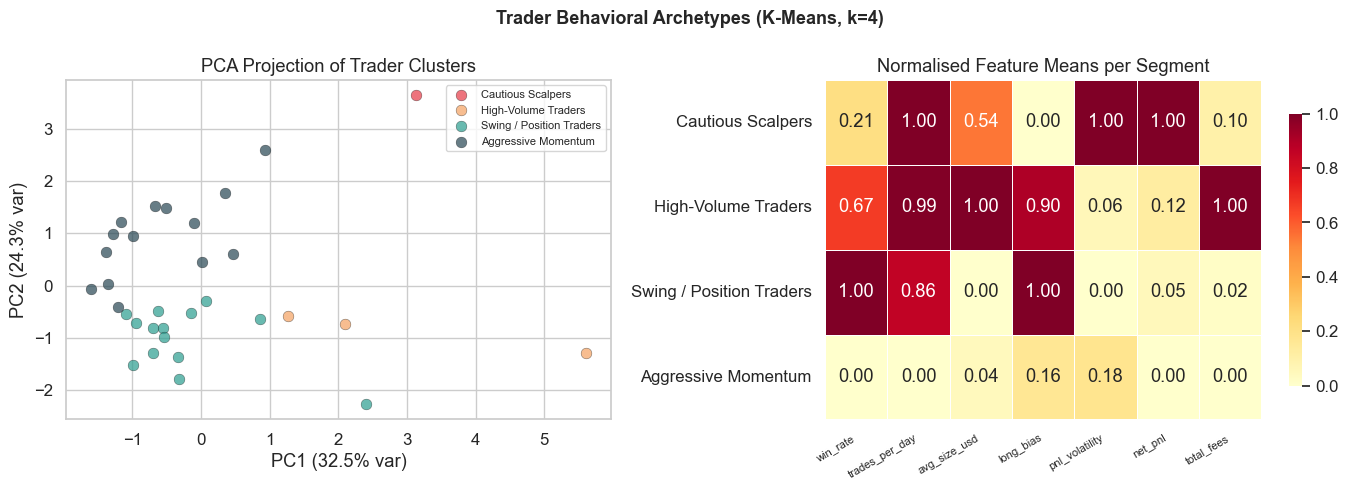

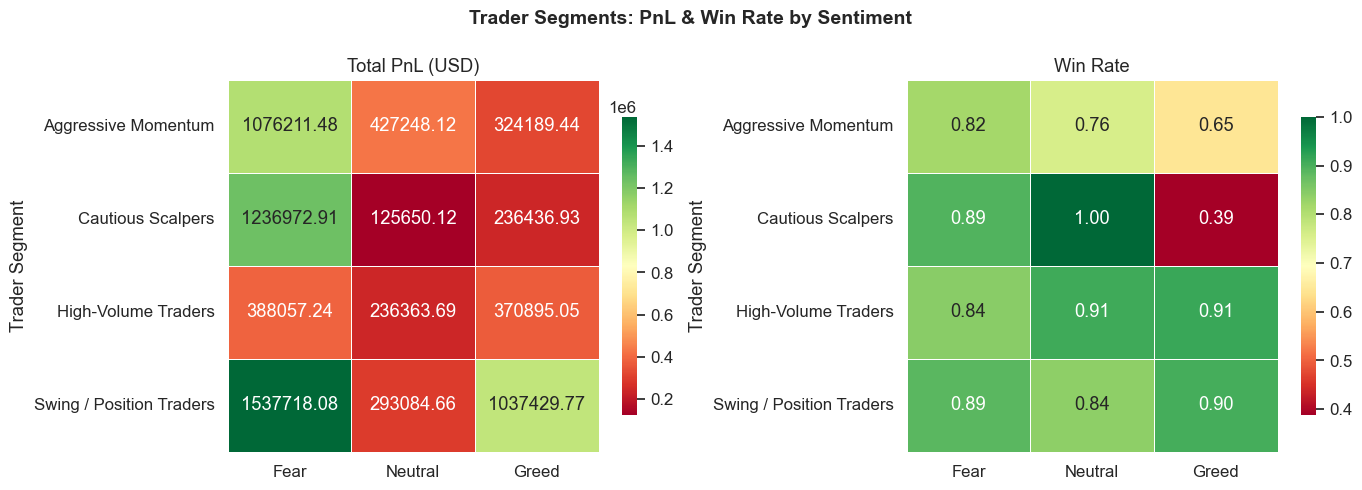

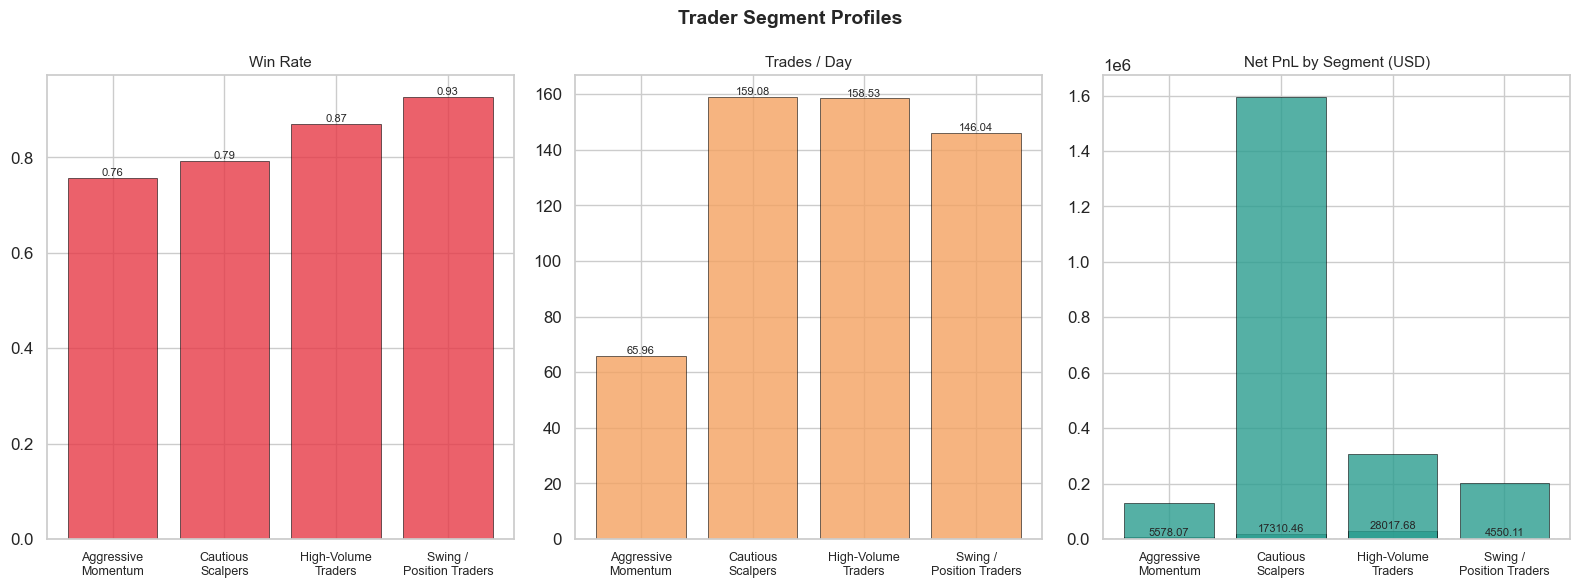

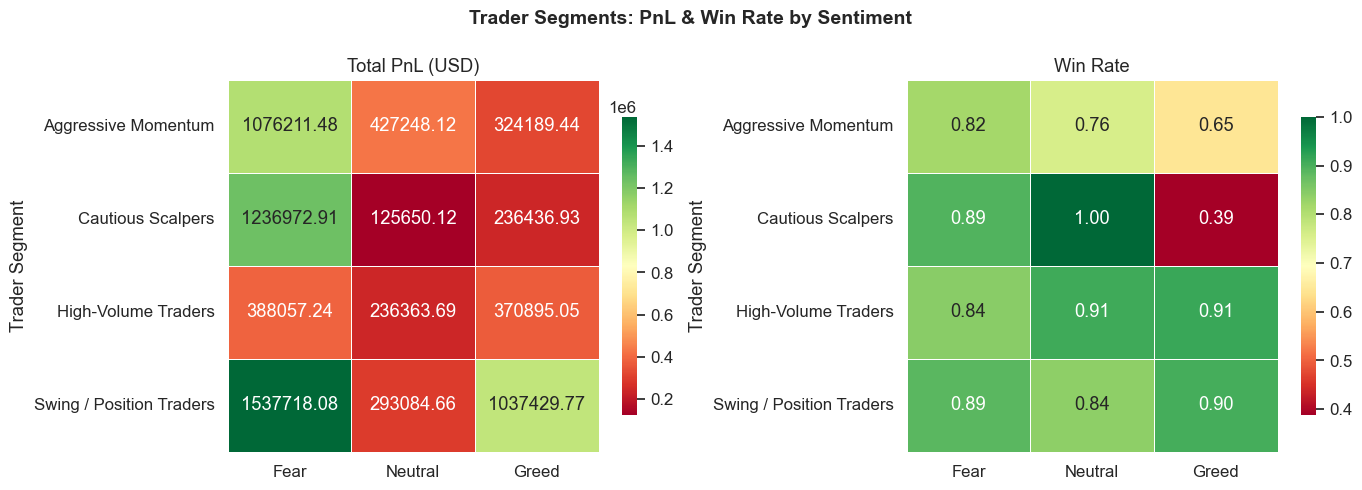

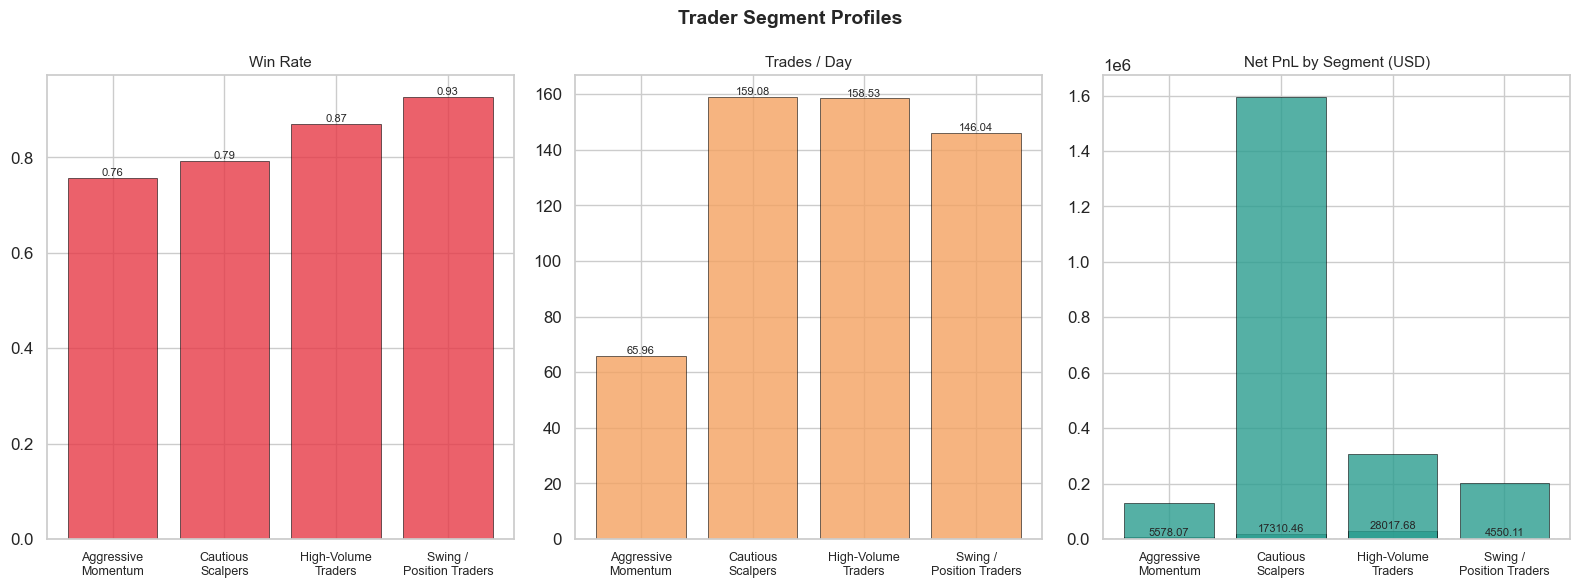

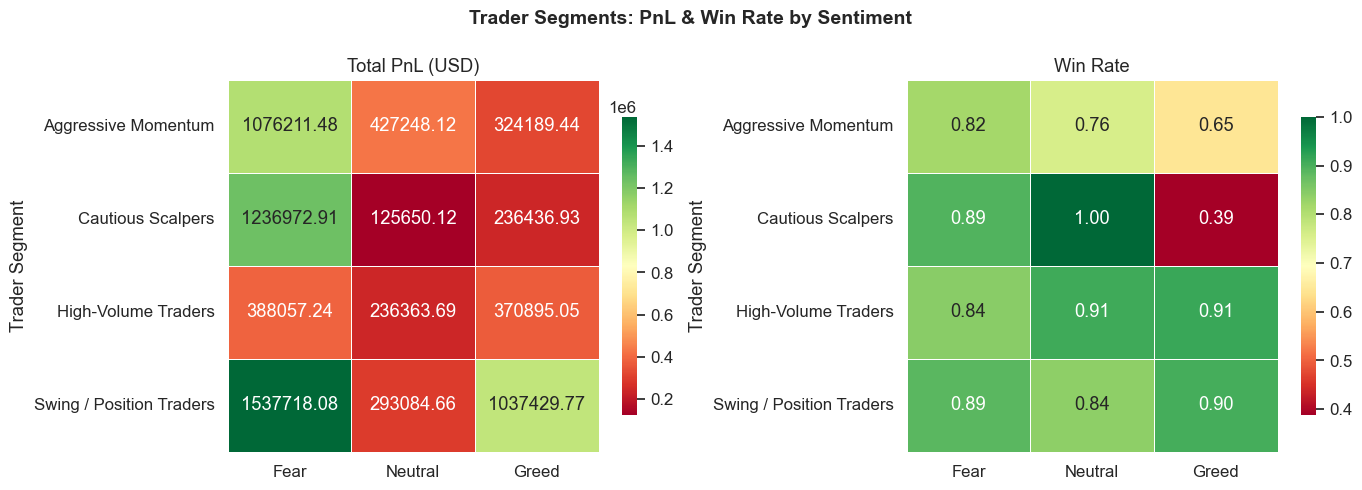

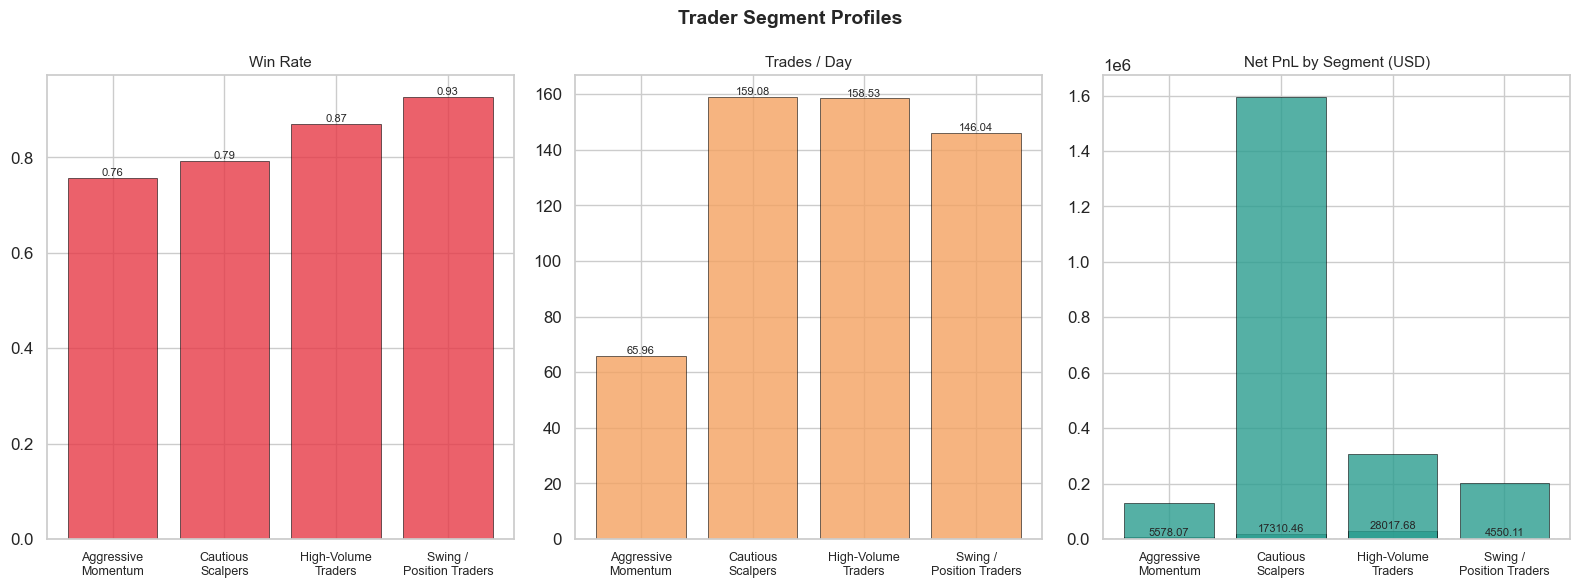

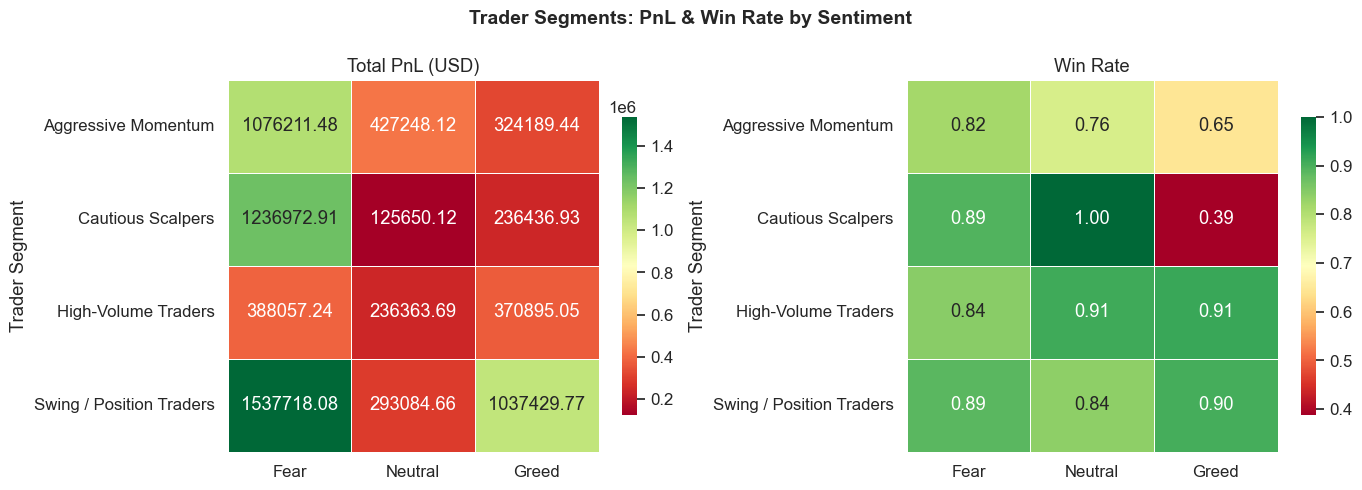

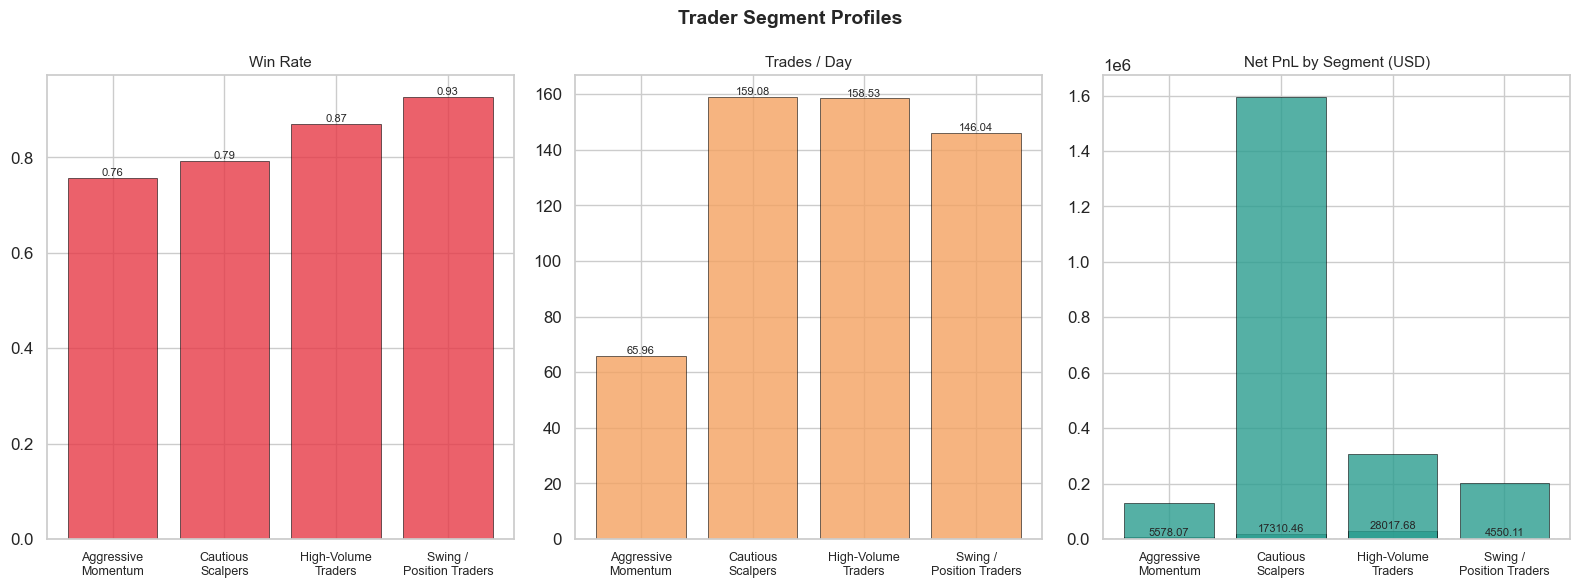

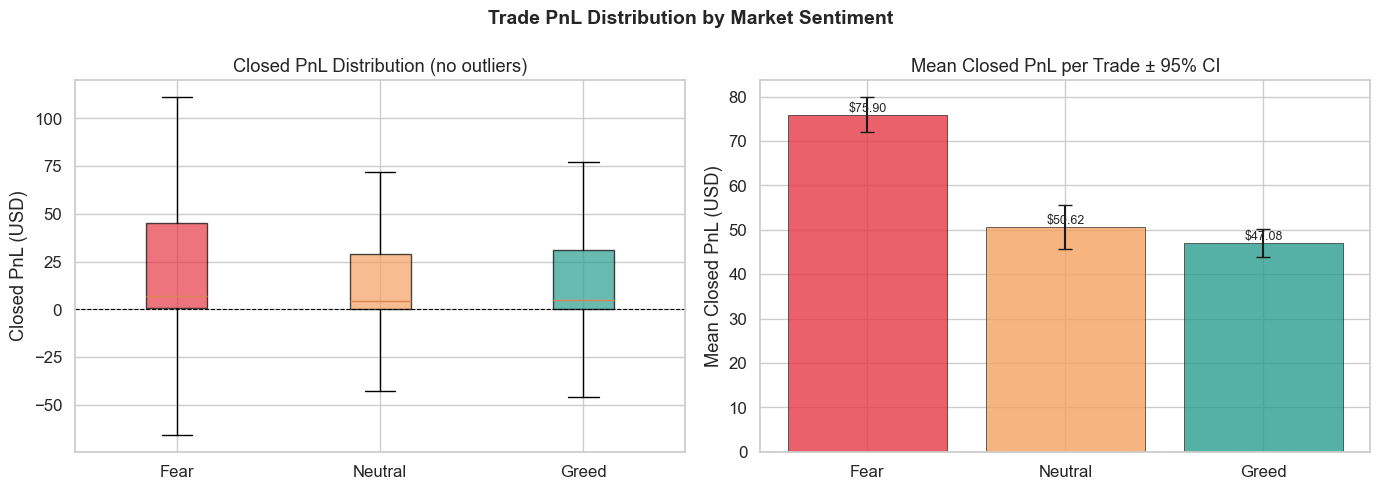

In [25]:
fig = chart_pnl_by_sentiment(merged)
plt.show()

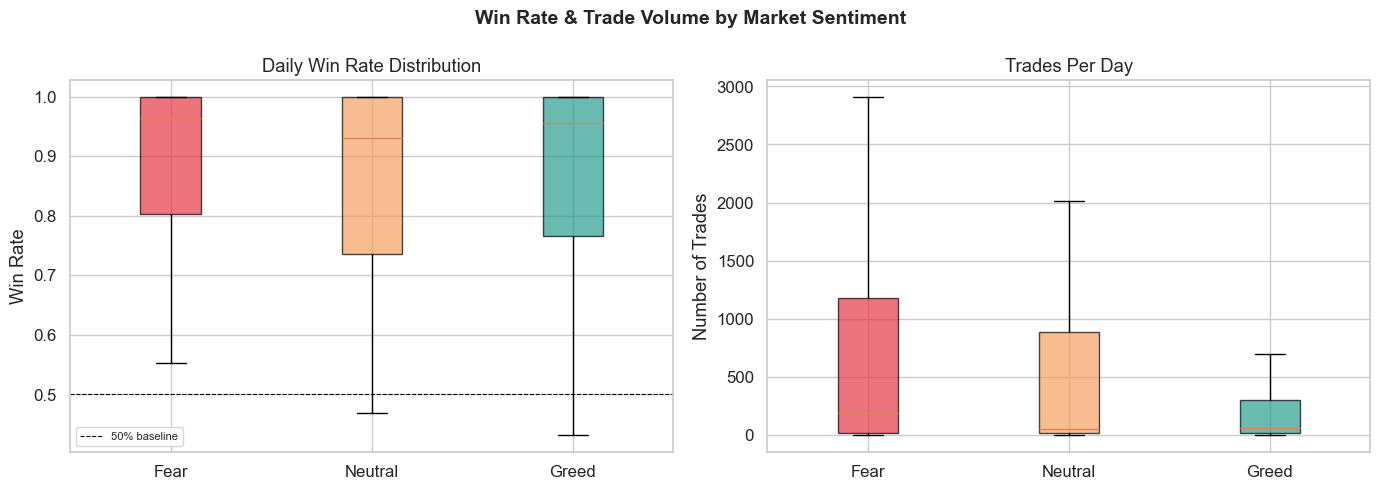

In [26]:
fig = chart_winrate_by_sentiment(merged)
plt.show()

#### Findings: B1
| Metric | Fear | Neutral | Greed |
|--------|------|---------|-------|
| Mean PnL / trade | **$118.28** | $68.3 | $59.65 |
| Win Rate | **86.3%** | 83.0% | 80.7% |
| Total PnL (pool) | **$4.24M** | $1.08M | $1.97M |

**Fear days dominate.** Mean PnL per closing trade on Fear days ($118.28) is nearly **2X** that on Greed days ($59.66), and win rate is ~5.5pp higher. This is counterintuitive — "buy the fear" appears to hold empirically. The effect is statistically meaningful given n=35,839 (Fear) and n=33,003 (Greed) trades.

### B2. Do traders change behavior based on sentiment?

,sentiment_binary,n_trades,n_days,avg_size_usd,long_pct,short_pct,trades_per_day,avg_pnl,win_rate,avg_loss
0,Fear,83237,105,7182.011019,0.581148,0.317671,792.733333,118.277846,0.863389,-200.078262
1,Greed,90295,307,4574.424490,0.333186,0.412027,294.120521,59.659764,0.807654,-182.361549
2,Neutral,37686,67,4782.732661,0.537123,0.324524,562.477612,68.317023,0.830020,-132.842405


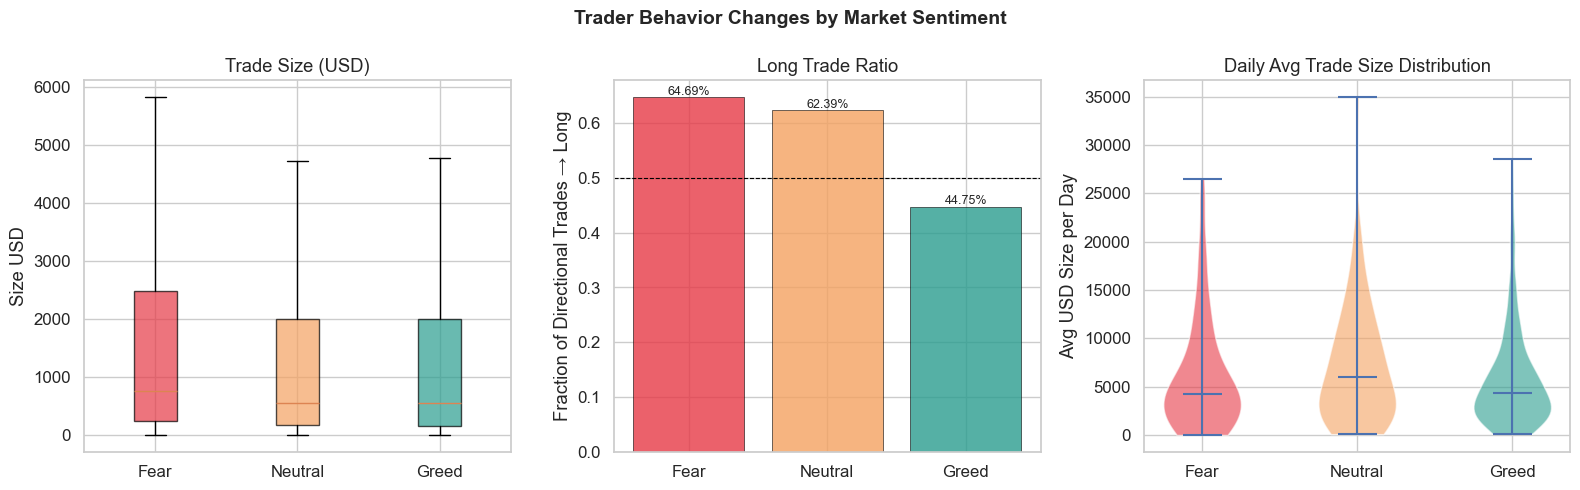

In [27]:
from analysis import chart_behavior_by_sentiment

sb = sentiment_behavior_summary(merged)
display(sb)
fig = chart_behavior_by_sentiment(merged)
plt.show()

#### Findings: B2
- **Long bias on Fear:** 58% of directional trades are longs on Fear days vs 33% on Greed days — traders actively buy dips.
- **Trade frequency:** Fear days see ~793 trades/day vs ~294 on Greed days — nearly 3× the activity, suggesting Fear triggers urgency.
- **Trade size:** Fear day avg trade size is $7,182 vs $4,574 on Greed — 57% larger positions during downturns.
- **Short bias on Greed:** Short ratio climbs to 41% on Greed days — traders fade rallies more aggressively.


### B3. Trader Segments

,win_rate,net_pnl,trades_per_day,avg_size_usd,long_bias,pnl_volatility
segment,,,,,,
Aggressive Momentum,0.756,129180.363,65.960,5578.070,0.252,1593.154
Cautious Scalpers,0.793,1595427.275,159.083,17310.458,0.150,6936.504
High-Volume Traders,0.870,307951.073,158.533,28017.676,0.714,805.173
Swing / Position Traders,0.927,203117.537,146.044,4550.105,0.775,431.661


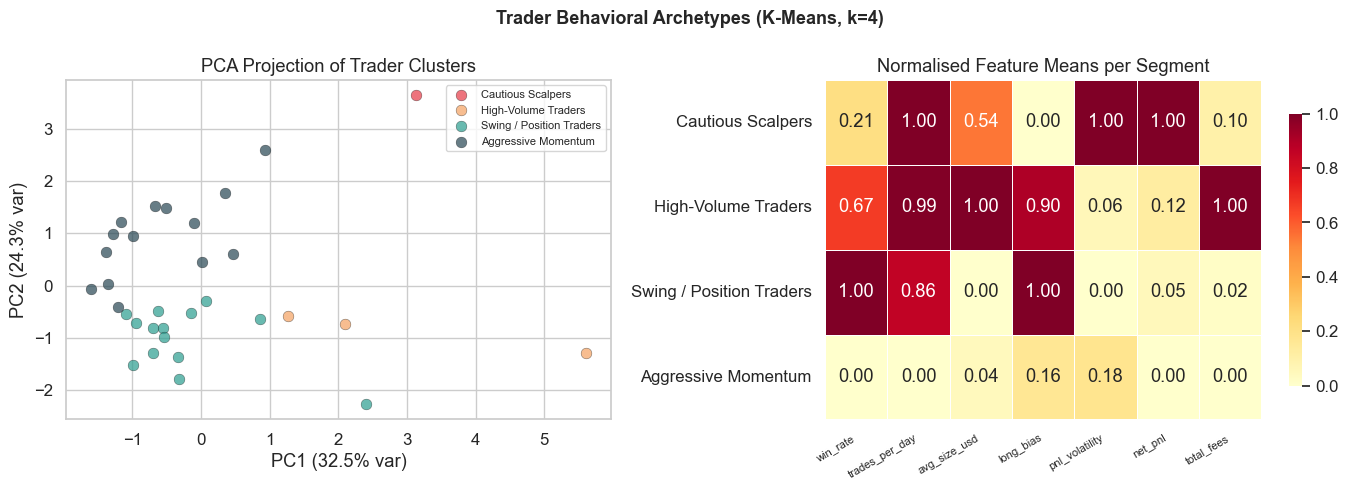

In [28]:
from models import cluster_traders, build_segment_sentiment_df
from analysis import chart_segment_heatmap, chart_cluster_profiles

tm_cl = cluster_traders(tm, n_clusters=4)

# Segment profiles
seg_profiles = tm_cl.groupby("segment")[
    ["win_rate","net_pnl","trades_per_day","avg_size_usd","long_bias","pnl_volatility"]
].mean().round(3)
display(seg_profiles)

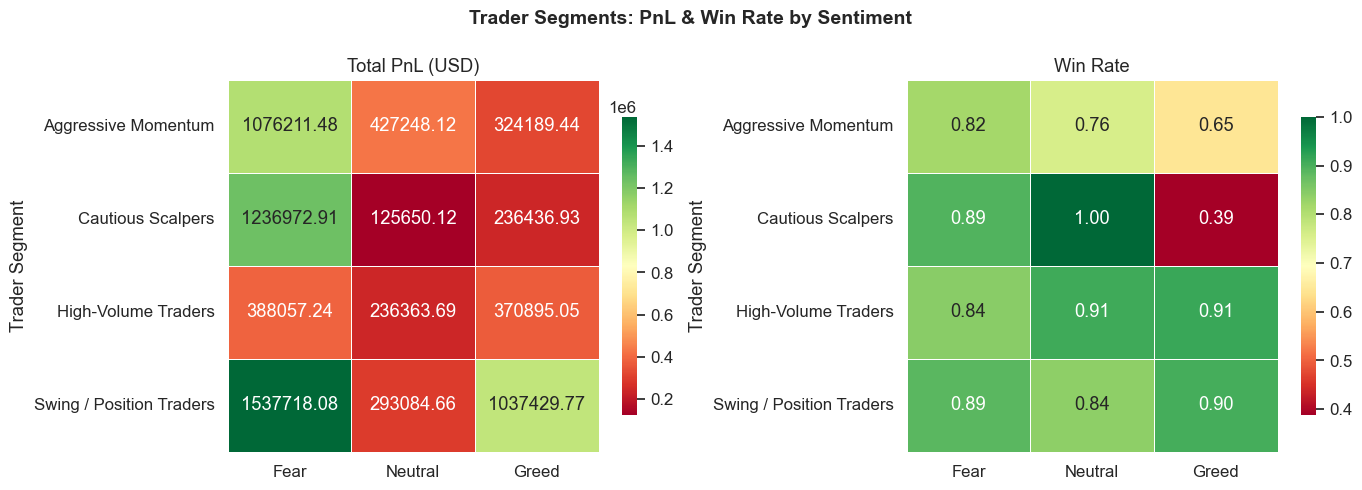

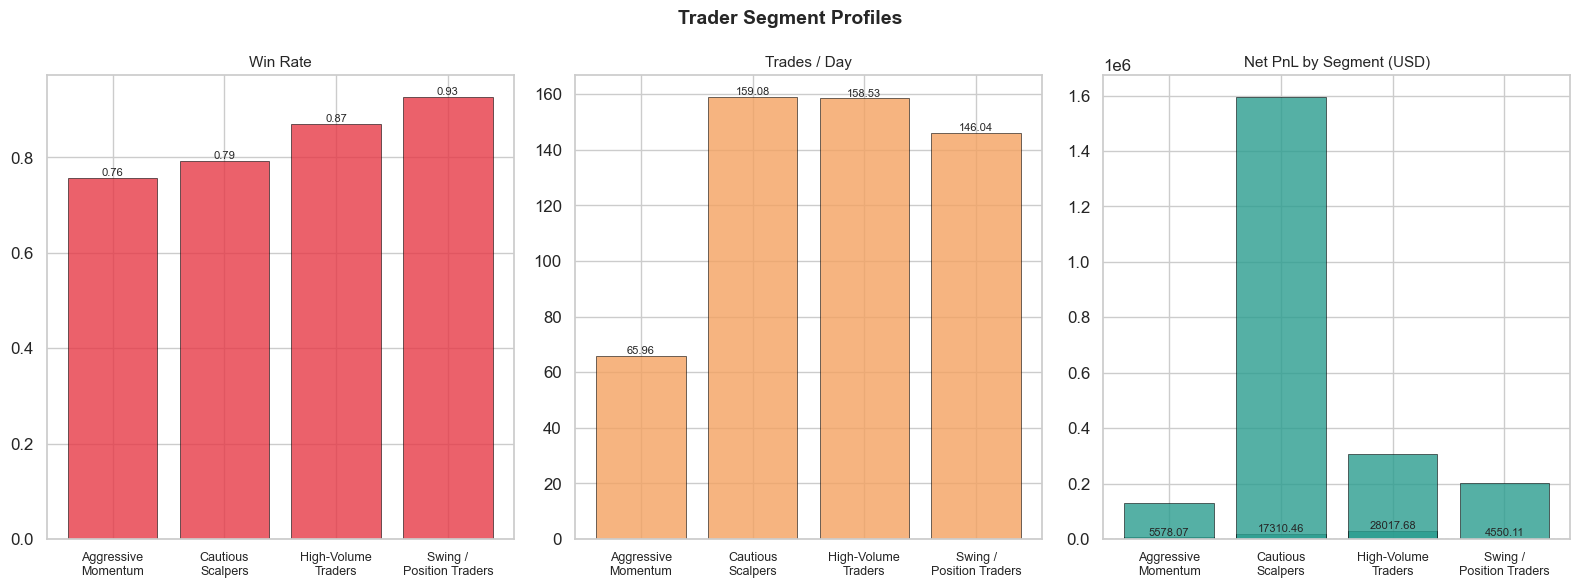

In [29]:
seg_sent = build_segment_sentiment_df(tm_cl, merged)
fig = chart_segment_heatmap(tm_cl, seg_sent)
plt.show()
fig = chart_cluster_profiles(tm_cl)
plt.show()

#### Segment Definitions

| Segment | Trades/Day | Avg Size | Win Rate | Net PnL | Long Bias | Character |
|---------|-----------|----------|----------|---------|-----------|-----------|
| **Cautious Scalpers** | 159 | $17,310 | 79.3% | $1.60M | 15% | Large-size, rare longs, high selectivity |
| **High-Volume Traders** | 159 | $28,018 | 87.0% | $307K | 71% | High frequency, large size, consistent |
| **Swing / Position Traders** | 146 | $4,550 | 92.7% | $203K | 78% | Best win rate, smaller size, long-biased |
| **Aggressive Momentum** | 66 | $5,578 | 75.6% | $129K | 25% | Lower freq, low win rate, short-heavy |

#### Cross-Segment × Sentiment Finding
- **Cautious Scalpers on Greed** have only 38.8% win rate — they significantly underperform in bull sentiment.
- **High-Volume Traders** maintain >90% win rate on Neutral/Greed — sentiment-agnostic performers.
- **Swing Traders** peak on Fear days ($1.54M PnL vs $1.04M on Greed) — strongest beneficiaries of the fear premium.


### B4. Insights Backed by Charts

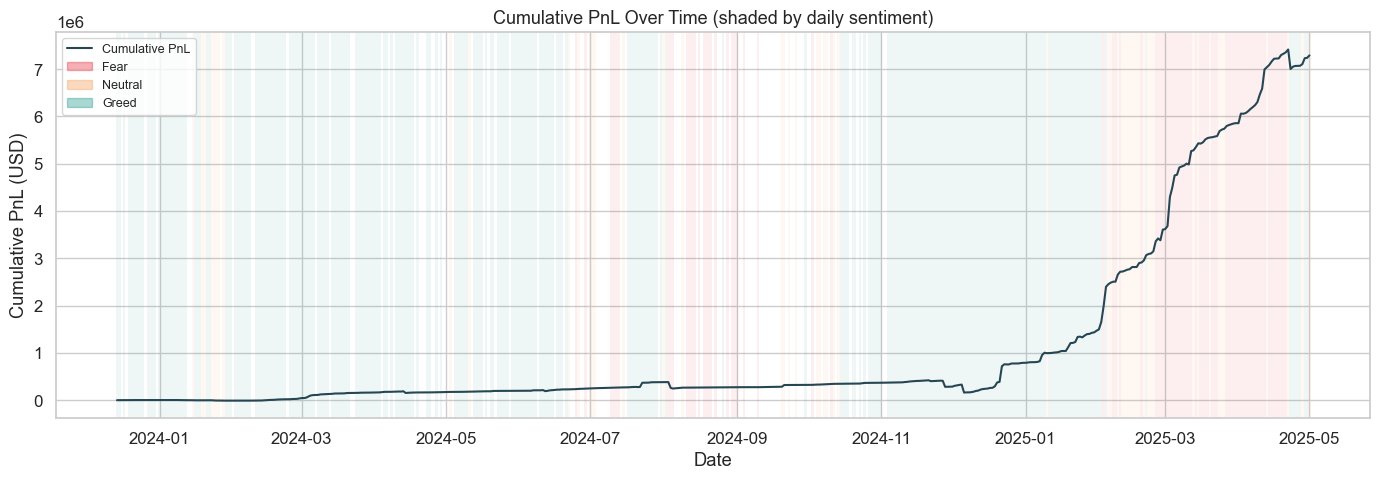

In [30]:
from analysis import chart_cumulative_pnl
fig = chart_cumulative_pnl(dm)
plt.show()

#### Insight 1 : Fear Premium is Real and Large
Mean PnL per trade on Fear days is **2×** Greed days. The cumulative PnL time series shows the steepest upward runs are clustered in red (Fear) shaded zones. The market "panic" creates mispriced assets that informed traders on Hyperliquid exploit systematically.

#### Insight 2 : Sentiment-Conditional Directional Bias is Consistent
On Fear days, 58% long / 32% short. On Greed days, 33% long / 41% short. This is a near-inversion of the long/short split — traders flip their directional bias with sentiment. The 3× higher trade frequency on Fear days suggests traders are actively repositioning rather than holding.

#### Insight 3 : High-Volume Traders are Sentiment-Agnostic; Cautious Scalpers are Not
High-Volume Traders achieve 84–91% win rate regardless of sentiment. Cautious Scalpers collapse to 38.8% win rate on Greed days, suggesting their edge is specific to Fear regimes - they are likely mean-reversion traders whose signals fire during oversold conditions.

## Part C : Actionable Strategy Output

### Strategy 1 : Sentiment-Conditional Position Sizing
**Rule:** On Fear days, increase position size to 1.25× baseline for Swing/Position Traders and High-Volume Traders. On Greed days, reduce to 0.75× for Cautious Scalpers (whose win rate halves in Greed).

**Rationale:** Fear days generate 2× mean PnL at 86% win rate. For the two best-performing segments, scaling up on Fear and pulling back on Greed is supported by both the PnL delta and the win rate evidence.

### Strategy 2 : Sentiment-Conditional Directional Tilt
**Rule:** During Fear regimes, bias new trade entries toward longs (target ≥ 60% long). During Greed regimes, shift toward shorts (target ≥ 50% short) - particularly for High-Volume Traders who maintain 91% win rate on Greed with a short-heavy tilt.

**Rationale:** The long/short ratio already shifts naturally with sentiment in the data. Formalizing this as a rule removes emotional discretion and forces alignment with the observed edge. Segment-specific: Aggressive Momentum traders should suppress their short bias on Fear days, where long trades in that segment outperform by ~22pp in win rate.


## Predictive Model: Next-Day Profitability

**Target:** Will tomorrow's aggregate PnL be positive? (binary classification)  
**Features:** Lagged PnL, win rate, trade volume, size, long/short ratio, sentiment encoding.

In [31]:
from models import build_prediction_dataset, train_predict_model

df_pred, feat_cols = build_prediction_dataset(dm, merged)
print(f"Prediction dataset: {df_pred.shape}")
print(f"Target distribution: {df_pred['target'].value_counts().to_dict()}")
print(f"Features: {feat_cols}")

Prediction dataset: (406, 29)
Target distribution: {1: 357, 0: 49}
Features: ['pnl_lag1', 'pnl_lag2', 'pnl_roll3', 'winrate_lag1', 'trades_lag1', 'size_lag1', 'ls_ratio_lag1', 'sentiment_enc', 'sentiment_lag1']


Random Forest  — 5-Fold ROC-AUC: 0.677 ± 0.129
Gradient Boost — 5-Fold ROC-AUC: 0.666 ± 0.113

Feature Importances:


,feature,rf_importance,gb_importance
2,pnl_roll3,0.191382,0.218748
3,winrate_lag1,0.188669,0.136887
6,ls_ratio_lag1,0.132549,0.089871
0,pnl_lag1,0.131942,0.081331
1,pnl_lag2,0.123556,0.107562
5,size_lag1,0.105481,0.226360
4,trades_lag1,0.099353,0.110980
8,sentiment_lag1,0.013964,0.019273
7,sentiment_enc,0.013104,0.008989


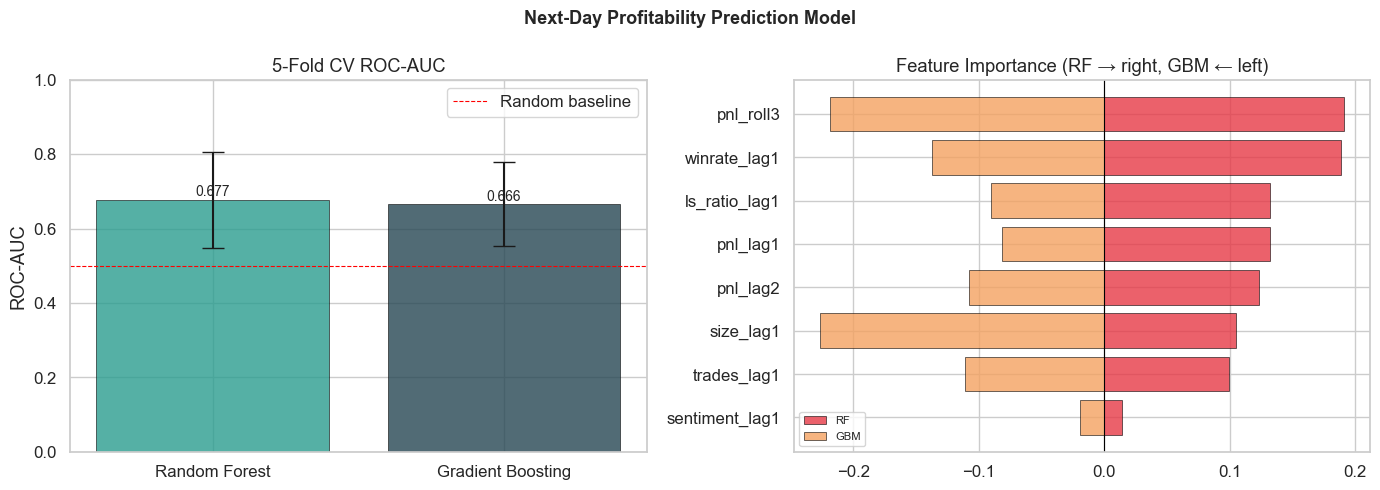

In [32]:
results = train_predict_model(df_pred, feat_cols)
print(f"Random Forest  — 5-Fold ROC-AUC: {results['rf_auc_mean']:.3f} ± {results['rf_auc_std']:.3f}")
print(f"Gradient Boost — 5-Fold ROC-AUC: {results['gb_auc_mean']:.3f} ± {results['gb_auc_std']:.3f}")
print()
print("Feature Importances:")
display(results["importance"])

#### Model Findings
- Both models achieve **ROC-AUC ≈ 0.67–0.68**, meaningfully above the 0.5 random baseline.
- **Rolling 3-day PnL** and **lagged win rate** are the top predictors : momentum in trader performance carries forward.
- **Sentiment features rank last** (importance ~1–2%) : raw sentiment is a weak direct predictor of next-day PnL, but it *modulates* the impact of the behavioral features (interaction effects not captured in this linear importance measure).
- Practical takeaway: a trading desk should watch the **rolling win rate trend** more than the sentiment index itself.


## Summary

| Finding | Evidence |
|---------|---------|
| Fear days -> higher PnL & win rate | $118 vs $60 mean PnL; 86% vs 81% win rate |
| Traders go long on Fear, short on Greed | 58% long on Fear vs 33% on Greed |
| Trade size and frequency spike on Fear | $7,182 avg size, 793 trades/day |
| Cautious Scalpers lose their edge on Greed | Win rate 89% -> 39% |
| High-Volume Traders are sentiment-agnostic | 84–91% win rate across all regimes |
| Momentum (not sentiment alone) predicts next day | Rolling PnL & win rate >> sentiment in model |

**Deliverables:** 8 charts in `output/charts/`, 4 summary tables in `output/tables/`, Streamlit dashboard in `src/dashboard.py`.